#  InSAR Burst Inspection with `phidown`

This notebook is a guided lesson on how to run and validate a Sentinel-1 burst search workflow using `phidown`.

You will learn how to:
- configure a burst-mode search for an Area of Interest (AOI),
- run the workflow from package APIs (no script subprocesses),
- validate the processing outputs,
- and interpret AOI coverage directly on an interactive Folium map.

## 0. Learning Objective and Inputs

Before running anything, define what this workflow should produce and how success is evaluated.

Inputs used in this lesson:
- AOI polygon in WKT format
- time window (`start_date`, `end_date`)
- burst search options (polarisation, optional orbit/swath/platform filters)

Expected outputs:
- `search_results.csv` with burst metadata
- `temporal_statistics.json` with revisit metrics
- `validation_report.json` with pass/fail checks

Success criterion:
- validation must pass (`validation['ok'] == True`) and footprints must be visualized on the AOI map.

In [1]:
from pathlib import Path
import pandas as pd
from phidown import run_burst_workflow, plot_product_footprints

pd.set_option('display.max_columns', None)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = Path('output') / 'insar_burst_validation_module'

config = {
    'search': {
        'aoi_wkt': 'POLYGON((12.4 41.8, 12.6 41.8, 12.6 42.0, 12.4 42.0, 12.4 41.8))',
        'start_date': '2025-01-01T00:00:00',
        'end_date': '2025-03-01T00:00:00',
        'polarisation': 'VV',
        'orbit_direction': None,
        'relative_orbit': None,
        'platforms': ['all'],
        'swath_identifier': None,
        'burst_id': None,
        'max_results': 300
    },
    'output_statistics': OUT_DIR.as_posix(),
    'save_results_csv': True
}



## 1. Run the Workflow

This step executes the full burst workflow via `run_burst_workflow(config)`.

What happens internally:
- the optimal orbit configuration is estimated for the AOI and date range,
- burst products are queried and ranked (coverage/subswath priority),
- temporal statistics are computed,
- lesson outputs are saved to the configured output folder.

In [2]:
result = run_burst_workflow(config)
df = result['df']
stats = result['stats']
validation = result['validation']
debug = result['debug']
paths = result['paths']

print('Rows:', len(df))
print('Orbit:', result['orbit'])
print('Output files:', {k: Path(v).as_posix() for k, v in paths.items()})


INFO:phidown.search:Analyzing ASCENDING orbits...
INFO:phidown.search:Analyzing DESCENDING orbits...
INFO:phidown.search:Analyzing ASCENDING orbits...
INFO:phidown.search:Analyzing DESCENDING orbits...


Rows: 8
Orbit: {'analysis': {'ascending': {'orbits': {117: {'avg_coverage': 100.0, 'max_coverage': 100.0, 'count': 4}}, 'best_orbit': 117, 'max_coverage': 100.0}, 'descending': {'orbits': {22: {'avg_coverage': 82.79, 'max_coverage': 97.62, 'count': 10}, 95: {'avg_coverage': 63.63, 'max_coverage': 100.0, 'count': 10}}, 'best_orbit': 22, 'max_coverage': 82.79}, 'recommended': {'orbit_direction': 'ASCENDING', 'relative_orbit': 117, 'expected_coverage': 100.0}}, 'orbit_direction': 'ASCENDING', 'relative_orbit': 117}
Output files: {'search_results_csv': 'output/insar_burst_validation_module/search_results.csv', 'temporal_statistics_json': 'output/insar_burst_validation_module/temporal_statistics.json', 'validation_report_json': 'output/insar_burst_validation_module/validation_report.json', 'debug_summary_json': 'output/insar_burst_validation_module/debug_summary.json', 'coverage_plot_png': 'output/insar_burst_validation_module/coverage_results.png'}


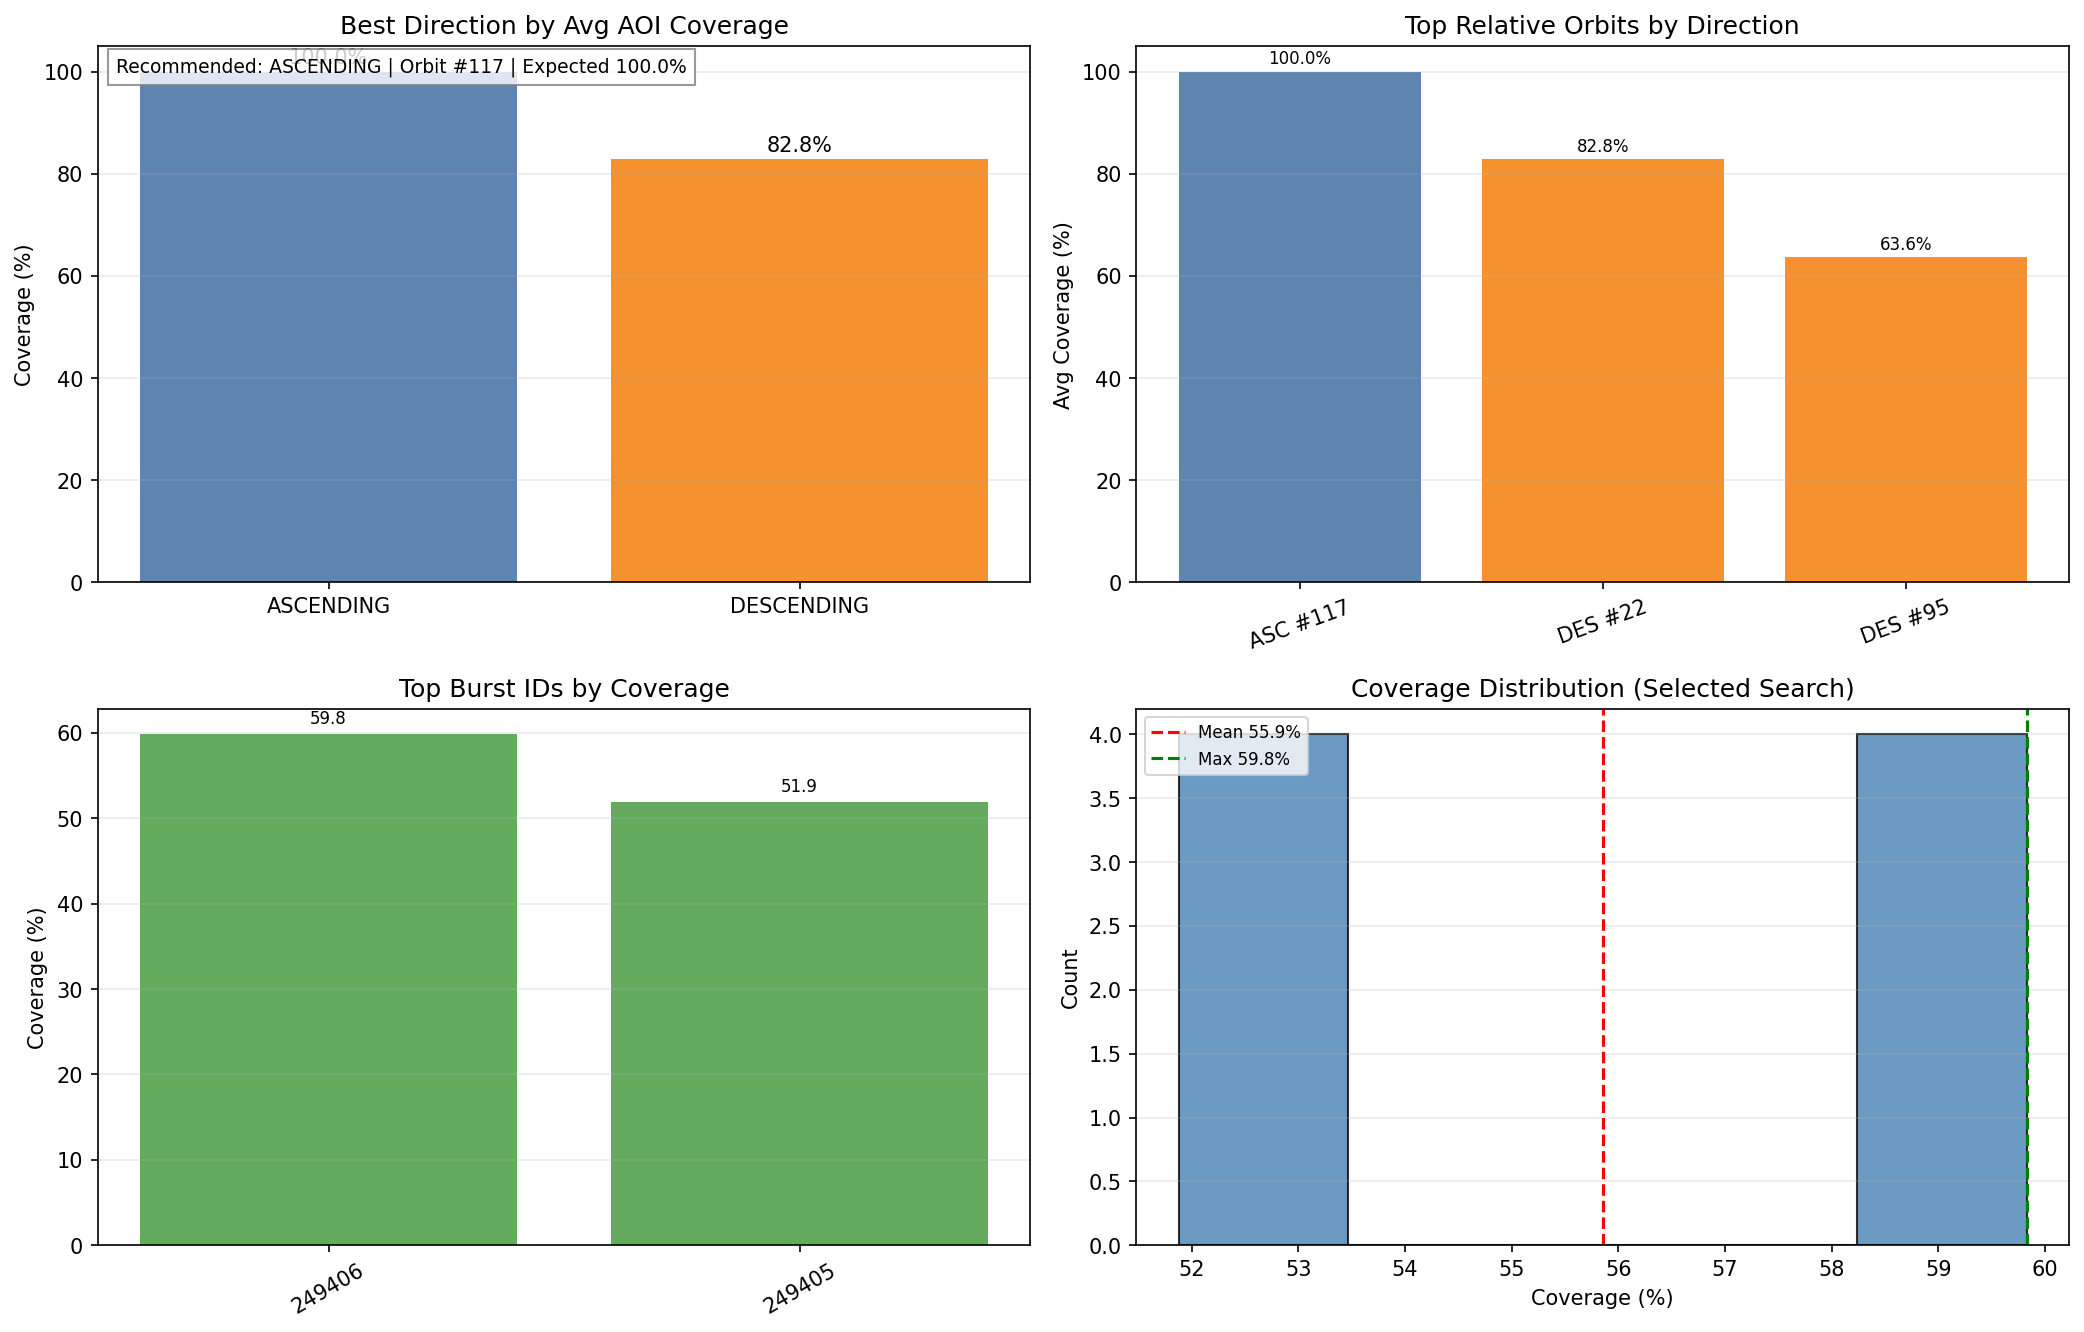

In [3]:
from IPython.display import display, Image
coverage_plot = paths.get('coverage_plot_png')
if coverage_plot:
    display(Image(filename=Path(coverage_plot).as_posix()))
else:
    print('Coverage plot not available.')


In [4]:
analysis = (result.get('orbit') or {}).get('analysis', {})
recommended = analysis.get('recommended', {})
print('Recommended:', recommended)

for direction_key in ['ascending', 'descending']:
    block = analysis.get(direction_key, {})
    orbits = block.get('orbits', {})
    rows = []
    for orb, vals in orbits.items():
        rows.append({
            'direction': direction_key.upper(),
            'relative_orbit': int(orb),
            'avg_coverage': vals.get('avg_coverage'),
            'max_coverage': vals.get('max_coverage'),
            'count': vals.get('count'),
        })
    if rows:
        print(f'\nTop {direction_key.upper()} relative orbits:')
        display(pd.DataFrame(rows).sort_values('avg_coverage', ascending=False).head(10))

if 'BurstId' in df.columns and 'coverage' in df.columns:
    work = df.assign(
        coverage_num=pd.to_numeric(df['coverage'], errors='coerce'),
        relative_orbit_norm=pd.to_numeric(df.get('RelativeOrbitNumber'), errors='coerce')
    ).dropna(subset=['coverage_num'])

    burst_cov = (
        work.groupby('BurstId', dropna=True)['coverage_num']
            .agg(['max', 'mean', 'count'])
            .reset_index()
            .rename(columns={'max': 'max_coverage', 'mean': 'avg_coverage'})
    )

    burst_orbit = (
        work.dropna(subset=['relative_orbit_norm'])
            .groupby('BurstId', dropna=True)['relative_orbit_norm']
            .agg(lambda s: int(s.mode().iloc[0]) if not s.mode().empty else int(s.iloc[0]))
            .reset_index()
            .rename(columns={'relative_orbit_norm': 'relative_orbit'})
    )

    burst_table = (
        burst_cov.merge(burst_orbit, on='BurstId', how='left')
                 .sort_values('max_coverage', ascending=False)
    )
    print('\nTop BurstIds by coverage (selected orbit search):')
    display(burst_table[['BurstId', 'relative_orbit', 'max_coverage', 'avg_coverage', 'count']].head(15))


Recommended: {'orbit_direction': 'ASCENDING', 'relative_orbit': 117, 'expected_coverage': 100.0}

Top ASCENDING relative orbits:


,direction,relative_orbit,avg_coverage,max_coverage,count
0,ASCENDING,117,100.0,100.0,4



Top DESCENDING relative orbits:


,direction,relative_orbit,avg_coverage,max_coverage,count
0,DESCENDING,22,82.79,97.62,10
1,DESCENDING,95,63.63,100.00,10



Top BurstIds by coverage (selected orbit search):


,BurstId,relative_orbit,max_coverage,avg_coverage,count
1,249406,117,59.83,59.83,4
0,249405,117,51.88,51.88,4


## 2. Validate the Results

This section enforces the quality gate for the lesson.

Validation confirms that:
- required columns are present,
- search results are not empty,
- and temporal statistics were generated correctly.

If the assertion fails, review your AOI/time range first, then relax filters (orbit/swath/platform).

In [5]:
assert validation['ok'], f"Validation failed: {validation['errors']}"
print('Validation passed. Rows:', len(df))
df.head(10)

Validation passed. Rows: 8


,@odata.mediaContentType,Id,Name,ContentType,S3Path,ContentDate,Footprint,GeoFootprint,ParentProductId,ParentProductName,ByteOffset,BurstId,AbsoluteBurstId,AzimuthTime,AzimuthAnxTime,ParentProductType,SwathIdentifier,RelativeOrbitNumber,OrbitDirection,PlatformSerialIdentifier,PolarisationChannels,OperationalMode,DatatakeID,Lines,LinesPerBurst,SamplesPerBurst,BeginningDateTime,EndingDateTime,coverage,subswath_priority
0,application/octet-stream,8ff4f2b3-64d8-4852-8c3b-4b2b8f729b03,S1A-SLC-20250217T170613-249406-IW2-VV-468546,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/17/S...,"{'Start': '2025-02-17T17:06:13.727886Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",99c31c4e-0ed9-415d-bc59-393c9f753e1d,S1A_IW_SLC__1SDV_20250217T170559_20250217T1706...,640810107,249406,124446891,2025-02-17T17:06:12.711058Z,678.918613,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,468546,6048,1512,26484,2025-02-17T17:06:13.727886Z,2025-02-17T17:06:14.769476Z,59.83,1
1,application/octet-stream,2404a519-5e05-4dcc-95e5-b3e4e8a79127,S1A-SLC-20250205T170614-249406-IW2-VV-466741,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/05/S...,"{'Start': '2025-02-05T17:06:14.317745Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",cf6f847b-0634-4f93-b38f-a4d38b69bef9,S1A_IW_SLC__1SDV_20250205T170559_20250205T1706...,800997435,249406,124071003,2025-02-05T17:06:13.305030Z,678.925139,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,466741,7560,1512,26484,2025-02-05T17:06:14.317745Z,2025-02-05T17:06:15.359335Z,59.83,1
2,application/octet-stream,ed949647-6573-484a-a49c-913d80e51117,S1A-SLC-20250124T170614-249406-IW2-VV-464973,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/01/24/S...,"{'Start': '2025-01-24T17:06:14.811016Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",21332892-321f-4954-b01e-6247318c0c60,S1A_IW_SLC__1SDV_20250124T170600_20250124T1706...,640810107,249406,123695116,2025-01-24T17:06:13.792121Z,678.918260,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,464973,6048,1512,26484,2025-01-24T17:06:14.811016Z,2025-01-24T17:06:15.852606Z,59.83,1
3,application/octet-stream,cedb52f3-9e96-49b9-a6a3-d7b195c6918e,S1A-SLC-20250112T170615-249406-IW2-VV-463192,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/01/12/S...,"{'Start': '2025-01-12T17:06:15.657009Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",6b19852e-76d9-4d8f-872d-1e454a903b10,S1A_IW_SLC__1SDV_20250112T170601_20250112T1706...,640810107,249406,123319229,2025-01-12T17:06:14.638116Z,678.920017,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,463192,6048,1512,26484,2025-01-12T17:06:15.657009Z,2025-01-12T17:06:16.698599Z,59.83,1
4,application/octet-stream,ead48acc-c11b-418b-9aac-a550d8eee23f,S1A-SLC-20250217T170610-249405-IW2-VV-468546,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/17/S...,"{'Start': '2025-02-17T17:06:10.969609Z', 'End'...",geography'SRID=4326;POLYGON ((11.970216 41.641...,"{'type': 'Polygon', 'coordinates': [[[11.97021...",99c31c4e-0ed9-415d-bc59-393c9f753e1d,S1A_IW_SLC__1SDV_20250217T170559_20250217T1706...,480634875,249405,124446890,2025-02-17T17:06:09.958669Z,676.166224,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,468546,4536,1512,26484,2025-02-17T17:06:10.969609Z,2025-02-17T17:06:12.011199Z,51.88,1
5,application/octet-stream,dee9e6c1-b963-49a6-82ff-fed6581814b4,S1A-SLC-20250205T170611-249405-IW2-VV-466741,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/05/S...,"{'Start': '2025-02-05T17:06:11.559468Z', 'End'...",geography'SRID=4326;POLYGON ((11.970216 41.641...,"{'type': 'Polygon', 'coordinates': [[[11.97021...",cf6f847b-0634-4f93-b38f-a4d38b69bef9,S1A_IW_SLC__1SDV_20250205T170559_20250205T1706...,640822203,249405,124071002,2025-02-05T17:06:10.552640Z,676.172749,IW_SLC__1S,IW

## 3. Area Visualisation: AOI and Footprint Coverage

The map overlays the AOI and burst footprints.

How to read it:
- each footprint includes AOI coverage in the tooltip/popup,
- footprint colors encode coverage intensity (lower to higher),
- this helps verify spatial relevance before any downstream processing or downloads.

In [6]:
df_map = df.copy()
if 'coverage' in df_map.columns:
    df_map['coverage'] = pd.to_numeric(df_map['coverage'], errors='coerce')
    df_map = df_map[df_map['coverage'] > 0].copy()

print(f"Bursts shown on map (coverage > 0): {len(df_map)}")

m = plot_product_footprints(
    df=df_map,
    aoi_wkt=config['search']['aoi_wkt'],
    top_n=len(df_map),
    name_col='ParentProductName',
    id_col='Id',
    group_by='product',
    add_layer_control=True
)
m


Bursts shown on map (coverage > 0): 8
